In [1]:
from QiskitTranspiler.transpiler.passes.layout.layout import Layout
from qiskit import QuantumCircuit
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_aer import AerSimulator
from QiskitTranspiler.transpiler.passes.translation.translator import translate_circuit
from qiskit.converters import circuit_to_dag, dag_to_circuit
from QiskitTranspiler.transpiler.transpile import transpile

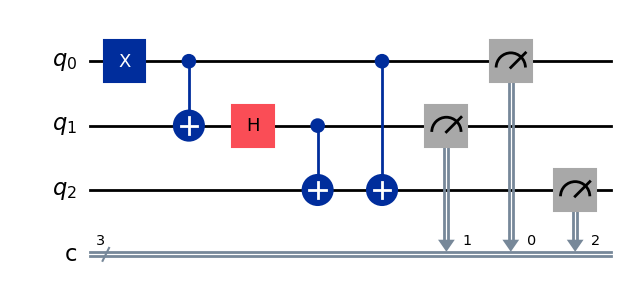

In [2]:
qc = QuantumCircuit(3, 3)
qc.x(0)
qc.cx(0, 1)
qc.h(1)
qc.cx(1, 2)
qc.cx(0, 2)
qc.measure([0, 1, 2], [0, 1, 2])
qc.draw("mpl")

{0: 140, 1: 141, 2: 142}


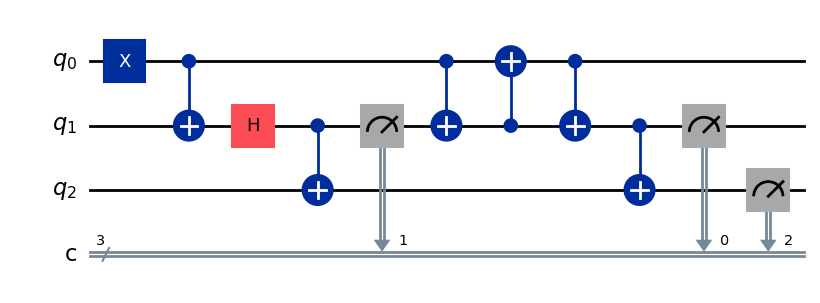

In [4]:
from QiskitTranspiler.transpiler.passes.layout.layout import Layout
from qiskit_ibm_runtime.fake_provider import FakeFez

backend = FakeFez()
routed_qc, mapping = Layout().run_layout(qc, backend)

print(mapping)

routed_qc.draw("mpl")

In [7]:
INFRASTRUCTURE_GATES = { "measure", "delay", "reset"}
CONTROL_FLOW_GATES = {"if_else", "for_loop", "switch_case", "while_loop", "break", "continue"}

basis_gates = [
    g for g in backend.operation_names 
    if g not in INFRASTRUCTURE_GATES and g not in CONTROL_FLOW_GATES
]

[BasisTranslator] Warning: Found a built-in equivalence table that covers the provided custom_basis. Using 'heron'


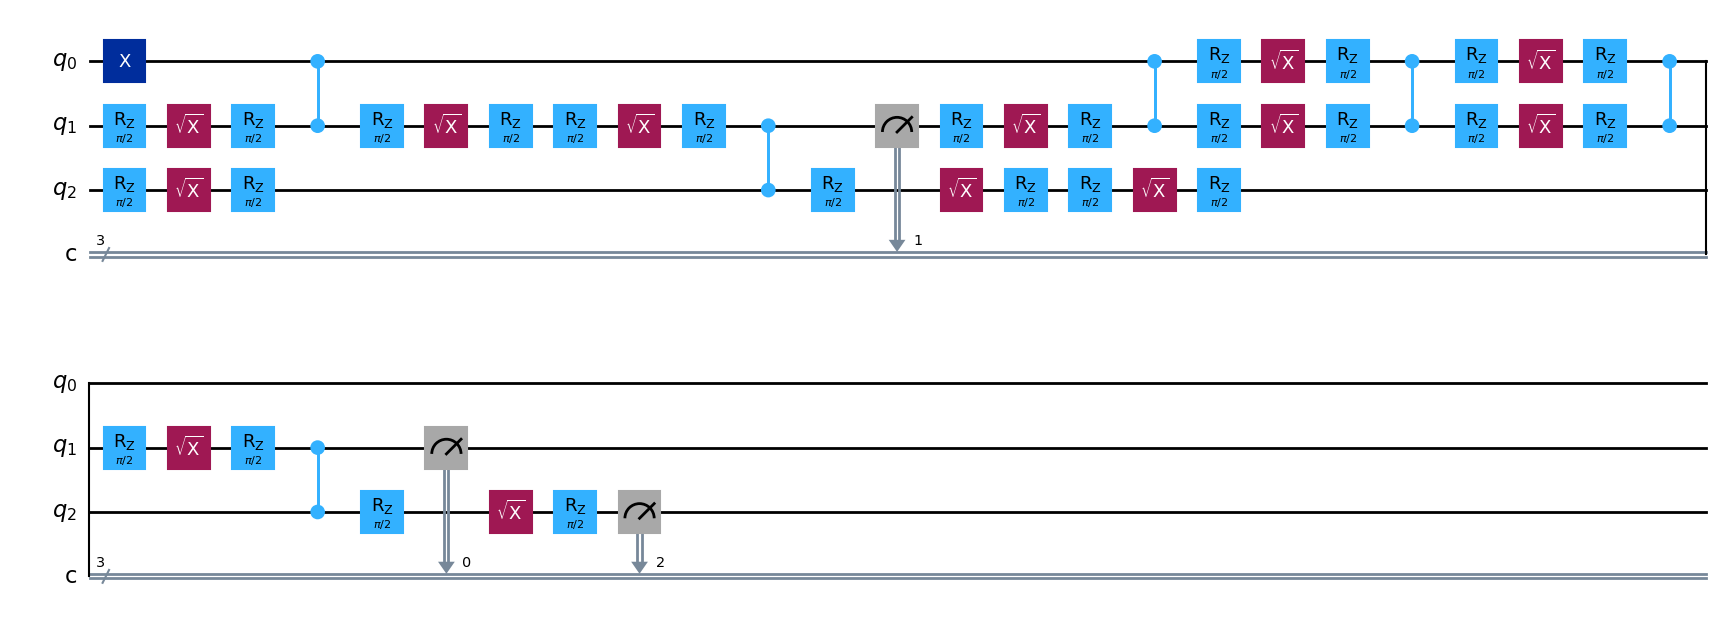

In [10]:
from QiskitTranspiler.transpiler.passes.translation.translator import translate_circuit
translated_circuit = translate_circuit(routed_qc, basis=basis_gates)
translated_circuit.draw("mpl")

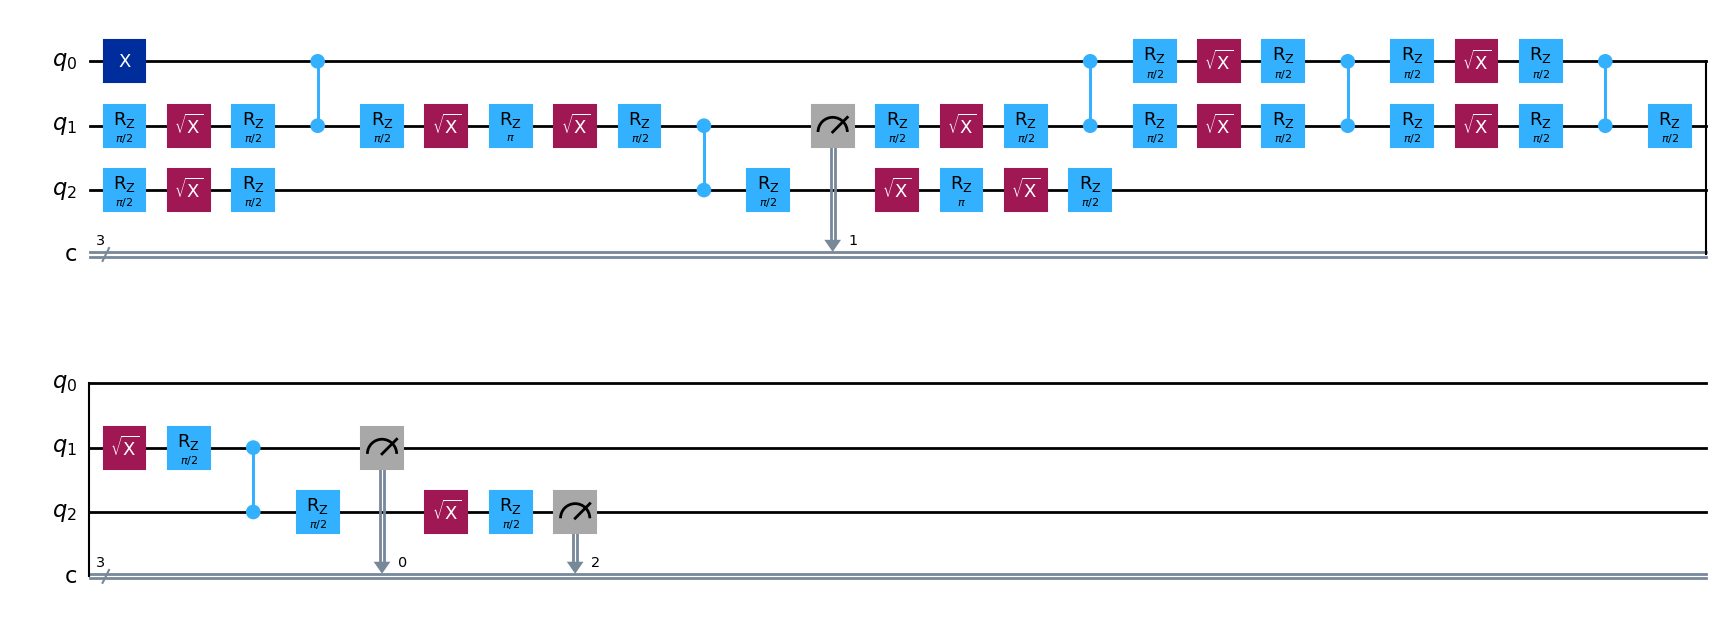

In [11]:
from QiskitTranspiler.transpiler.passes.optimization.optimization import optimize
optimized_circuit = optimize(translated_circuit)
optimized_circuit.draw("mpl")